In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from matplotlib import cm, colors           

In [3]:
#thank you to my CEGEP teacher for collaborating on this code with me! :p
mu0 = 4*np.pi*10**(-7)

epsilon = 1e-5
def A_ring(I, a, X, Y, Z):
    """Retourne les composantes cartésiennes du champ A en tout point de l'espace, 
    pour une boucle de rayon "a" portant un courant constant "I", placée dans le plan 
    z=z0, centrée sur (x,y)=(x0,y0)"""
    R = np.sqrt(X**2 + Y**2)                                    # Grille de coordonnées radiales
    phi_moins_pi_a_pi = np.arctan2(Y, X)
    phi = np.where(phi_moins_pi_a_pi < 0, phi_moins_pi_a_pi + 2*np.pi, phi_moins_pi_a_pi)     # Grille de coordonnées azimuthales (non nécessaire ici)

    k = np.sqrt(4*a*R / (Z**2 + (a + R)**2))                    # Paramètre k des fonctions elliptiques
    m = k**2                                                    # Paramètre m pour s'ajuster à la notation de SymPy
   
    Ax = np.where(R > 0, mu0*I/(2*np.pi) * (2/k*np.sqrt(a/R)*sp.ellipk(m) - 2/k*np.sqrt(a/R)*sp.ellipe(m) - k*np.sqrt(a/R)*sp.ellipk(m)) * (-Y/R), R*0)
    Ay = np.where(R > 0, mu0*I/(2*np.pi) * (2/k*np.sqrt(a/R)*sp.ellipk(m) - 2/k*np.sqrt(a/R)*sp.ellipe(m) - k*np.sqrt(a/R)*sp.ellipk(m)) * (X/R), R*0)
    Az = R*0

    return Ax, Ay, Az


def B_ring(I, a, X, Y, Z):
    """Retourne les composantes cartésiennes du champ B en tout point de l'espace, 
    pour une boucle de rayon "a" portant un courant constant "I", placée dans le plan 
    z=z0, centrée sur (x,y)=(x0,y0)"""
    R = np.sqrt(X**2 + Y**2)                              # Grille de coordonnées radiales
    phi_moins_pi_a_pi = np.arctan2(Y, X)
    phi = np.where(phi_moins_pi_a_pi < 0, phi_moins_pi_a_pi + 2*np.pi, phi_moins_pi_a_pi)     # Grille de coordonnées azimuthales (non nécessaire ici)

    k = np.sqrt(4*a*R / (Z**2 + (a + R)**2))                    # Paramètre k des fonctions elliptiques
    m = k**2                                                    # Paramètre m pour s'ajuster à la notation de SymPy
    
    Bz = mu0*I/(2*np.pi) * (Z**2 + (a + R)**2)**(-1/2) * ( (a**2 - Z**2 - R**2)/(Z**2 + (R - a)**2)*sp.ellipe(m) + sp.ellipk(m))
    Bx = np.where(R > 0, mu0*I/(2*np.pi) * Z/R * (Z**2 + (a + R)**2)**(-1/2) * ( (Z**2 + R**2+a**2)/(Z**2 + (R - a)**2)*sp.ellipe(m) - sp.ellipk(m)) * X/R, R*0)
    By = np.where(R > 0, mu0*I/(2*np.pi) * Z/R * (Z**2 + (a + R)**2)**(-1/2) * ( (Z**2 + R**2+a**2)/(Z**2 + (R - a)**2)*sp.ellipe(m) - sp.ellipk(m)) * Y/R, R*0)
    
    return Bx, By, Bz


#I need to write a function that can compute the on axis magnetic field without leading to singularities

def B_ring_on_axis(I, a, Z):
    return mu0 *I * a**2 /(2*(Z**2 + a**2))**(3/2)
    
    
    

In [10]:
print(sp.ellipk(0))

1.5707963267948966


In [11]:
xB = np.linspace(-3, 3, num=1000)
zB = np.linspace(-2, 2, num=1000)
X, Z = np.meshgrid(xB, zB)

Bx, By, Bz = B_ring(1, 1, X, X*0, Z)
normB = np.sqrt(Bx**2 + By**2 + Bz**2)

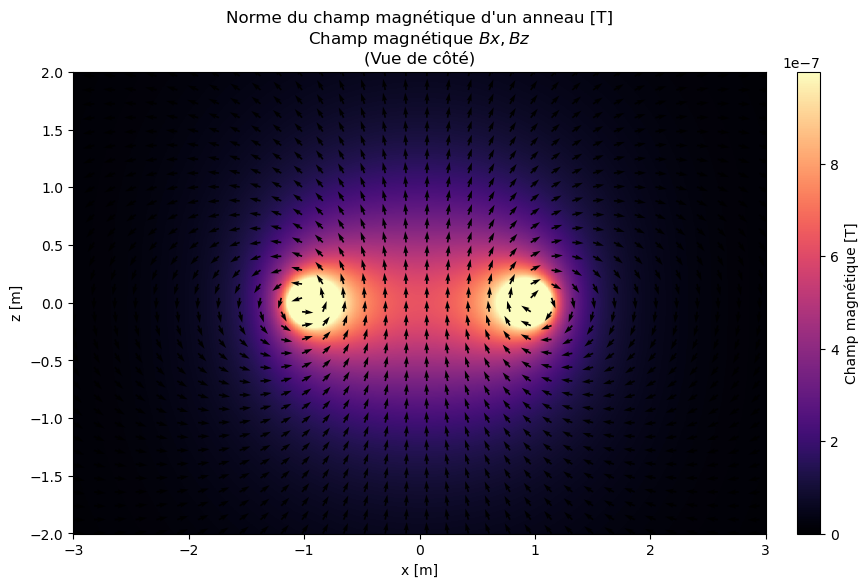

In [12]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

v3 = np.max(np.abs(normB))*1e-2
normalizer = colors.Normalize(0, v3)

colormesh = ax.pcolormesh(X, Z, normB, cmap=cm.magma, norm=normalizer)  # colormesh V(x,y)
#contours = ax.contour(X2, Y2, V_fil2, np.logspace(-2, 3, num=40, base=10), linewidths=0.5)                   # contours V(x,y)

cut = 30
max_len = 1e-8
Bx_capped = np.where(normB > max_len, Bx / normB * max_len, Bx)
Bz_capped = np.where(normB > max_len, Bz / normB * max_len, Bz)

B_field = ax.quiver(X[::cut, ::cut], Z[::cut, ::cut], Bx_capped[::cut,::cut], Bz_capped[::cut,::cut], color="black")      # Quiver, ajouter scale s'il faut

ax.set_title(r"Norme du champ magnétique d'un anneau [T]" + "\n" + r"Champ magnétique $Bx, Bz$" + "\n" + "(Vue de côté)")
plt.colorbar(colormesh, fraction=0.046, pad=0.04, label=r"Champ magnétique [T]")

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")

#plt.savefig("Champ B anneau", dpi=1000)
plt.show()

In [13]:

resolution = 1024
xB10 = np.linspace(-0.6, 0.6, num= resolution)
zB10 = np.linspace(-0.3, 0.3, num= resolution)
X10, Z10 = np.meshgrid(zB10, xB10)

Bx10, By10, Bz10 = np.zeros((resolution, resolution)), np.zeros((resolution, resolution)), np.zeros((resolution, resolution))

z0 = np.linspace(- 0.3125,0.3125 , num=5)

for z0i in z0:
    field = B_ring(150000, 0.135, X10, X10*0, Z10-z0i)
    
    Bx10 = np.add(Bx10, field[0])
    By10 = np.add(By10, field[1])
    Bz10 = np.add(Bz10, field[2])

normB10 = np.sqrt(Bx10**2 + By10**2 + Bz10**2)

#This cell takes the normB10 values and converts them into a binary file
#that is exported to Unity for real-time rendering (super-high resolution)

BFieldData = normB10.astype(np.float32)

# 2. Save raw binary
BFieldData.tofile('BFieldData.bytes')

print(f"Saved {BFieldData.size} values to binary.")


Saved 1048576 values to binary.


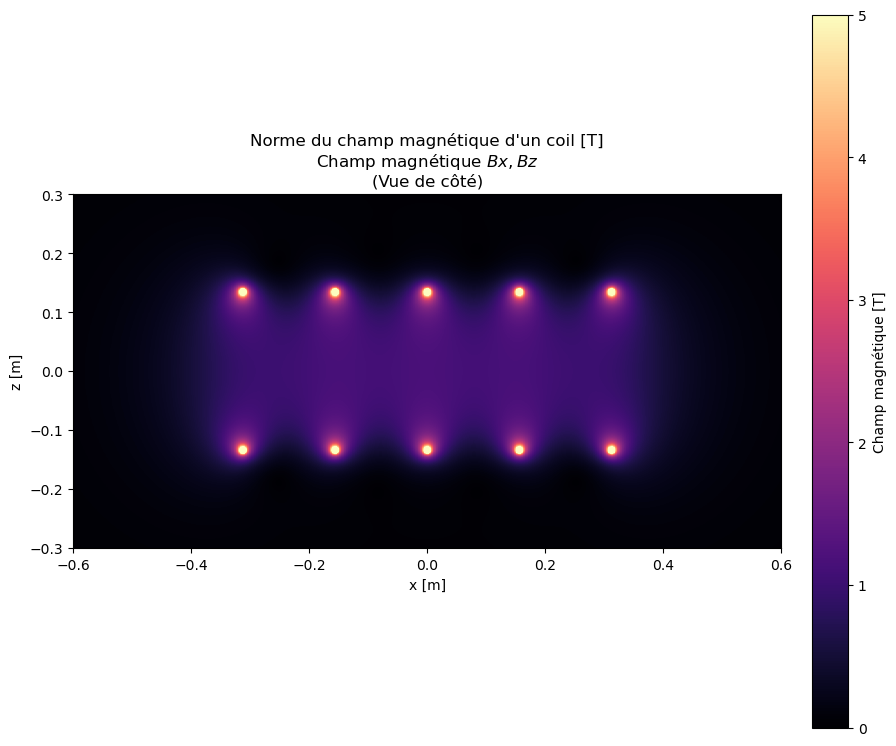

In [14]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

# Use the actual maximum value for the color scale
#v_max = np.max(normB10) 


# 1. Define the nuance range 
v_min = 0.0
v_max = 5

normalizer = colors.Normalize(vmin=v_min, vmax=v_max, clip=True)


colormesh = ax.pcolormesh(Z10, X10, normB10, cmap='magma', norm=normalizer)


cut = 40
ax_len = 1e-7
Bx10_capped = np.where(normB10 > max_len, Bx10 / normB10 * max_len, Bx10)
Bz10_capped = np.where(normB10 > max_len, Bz10 / normB10 * max_len, Bz10)

#B_field10 = ax.quiver(Z10[::cut, ::cut], X10[::cut, ::cut], Bz10_capped[::cut,::cut], Bx10_capped[::cut,::cut], color="cyan")      # Quiver, ajouter scale s'il faut

ax.set_title(r"Norme du champ magnétique d'un coil [T]" + "\n" + r"Champ magnétique $Bx, Bz$" + "\n" + "(Vue de côté)")
plt.colorbar(colormesh, fraction=0.046, pad=0.04, label=r"Champ magnétique [T]")

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")

plt.savefig("Champ B d'un coil", dpi=300)
plt.show()

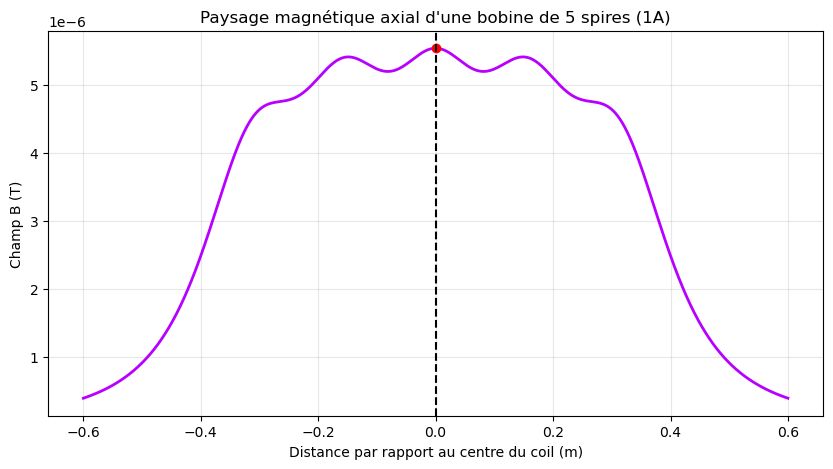

Fichier exporté : 400000 points générés.


In [15]:
import numpy as np
import matplotlib.pyplot as plt


res = 400000 #à vérifier

z_axis = np.linspace(-0.6, 0.6, num=res)


# 2. Paramètres physiques du Coil (pour 1 Ampère)
current_unit = 1
radius = 0.135
# Les anneaux réparties pour simuler la géométrie d'un coil
z0_rings = np.linspace(-0.3125, 0.3125, num=5)

#Compute the the axial B field

bz_signature = np.zeros(res)

for z0i in z0_rings:
    # On calcule la distance relative de chaque point de l'axe par rapport à l'anneau i
    z_rel = z_axis - z0i
    #Sur l'axe central, X=0 et Y=0
    field = B_ring_on_axis(current_unit, radius, z_rel)
    bz_signature += field # On additionne la composante Bz

#Export to Unity (if need be)

bz_signature.astype(np.float32).tofile('B_Coil_Unit_Signature.bytes')


# 5. Visualisation pour validation
plt.figure(figsize=(10, 5))
plt.plot(z_axis, bz_signature, color="#B700FF", linewidth=2)

# Marker 'o' creates a dot
plt.plot(0, bz_signature.max(), marker='o', markersize=6, color="red")
plt.axvline(x = 0, linestyle = '--', color = 'black')
plt.title("Paysage magnétique axial d'une bobine de 5 spires (1A)")
plt.xlabel("Distance par rapport au centre du coil (m)")
plt.ylabel("Champ B (T)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fichier exporté : {res} points générés.")


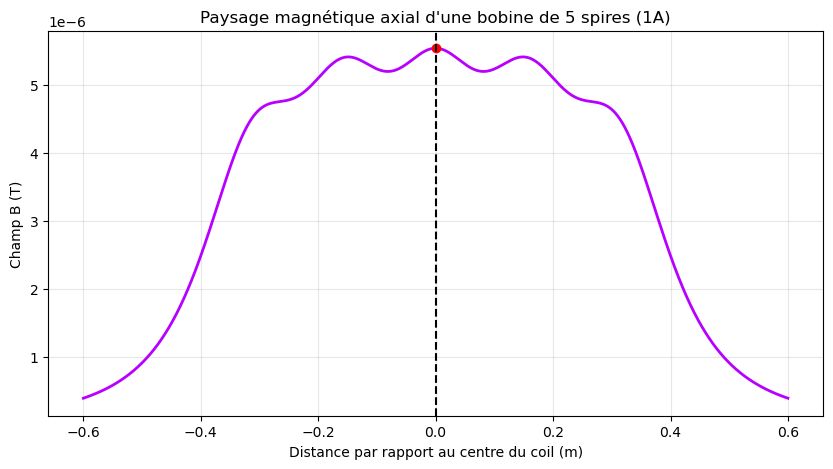

Fichier exporté : 400000 points générés.
      Time  Position  Velocity  Acceleration  MagGradient   KineticE  \
0   0.0000  0.000000  0.000000      0.000000     0.227928   0.000000   
1   0.0002  0.000008  0.037879      9.469863     0.444463   0.071743   
2   0.0004  0.000023  0.075759     18.466350     0.650174   0.286974   
3   0.0006  0.000046  0.113640     27.013130     0.845605   0.645700   
4   0.0008  0.000076  0.151521     35.132840     1.031270   1.147934   
5   0.0010  0.000114  0.189403     42.846740     1.207665   1.793683   
6   0.0012  0.000160  0.227288     50.175520     1.375254   2.582989   
7   0.0014  0.000214  0.265175     57.138440     1.534478   3.515879   
8   0.0016  0.000275  0.303064     63.753840     1.685757   4.592387   
9   0.0018  0.000343  0.340956     70.039090     1.829491   5.812540   
10  0.0020  0.000420  0.378851     76.010890     1.966057   7.176394   
11  0.0022  0.000504  0.416749     81.684880     2.095819   8.683979   
12  0.0024  0.000595  0

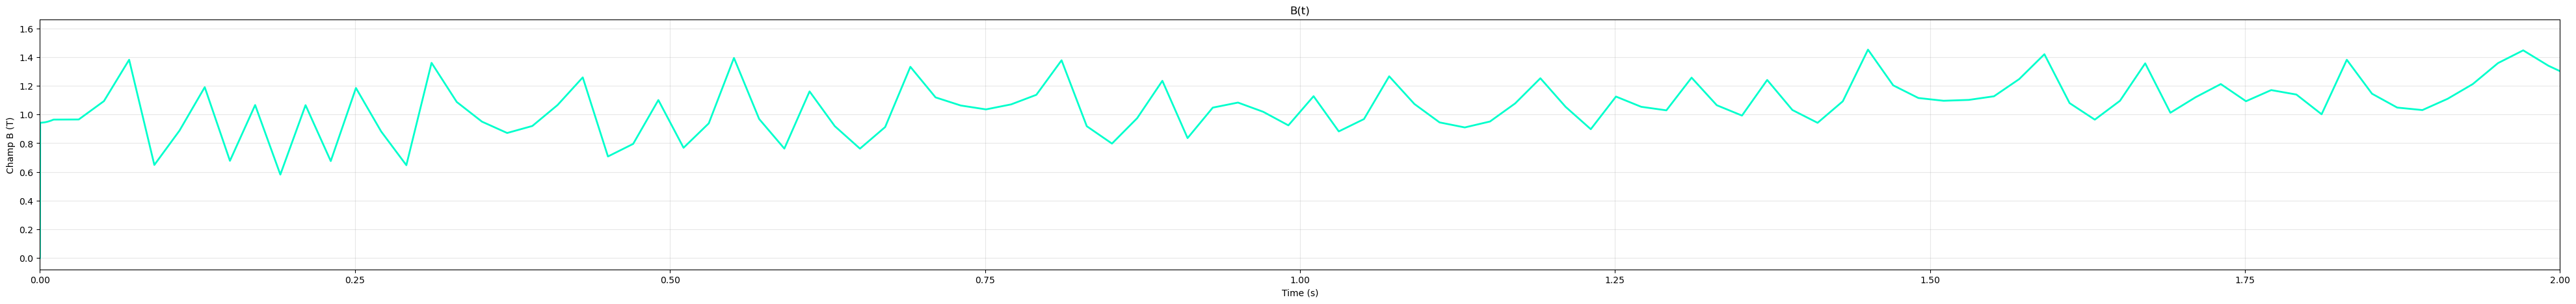

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt


res = 400000 #à vérifier

z_axis = np.linspace(-0.6, 0.6, num=res)


# 2. Paramètres physiques du Coil (pour 1 Ampère)
current_unit = 1
radius = 0.135
# Les anneaux réparties pour simuler la géométrie d'un coil
z0_rings = np.linspace(-0.3125, 0.3125, num=5)

#Compute the the axial B field

bz_signature = np.zeros(res)

for z0i in z0_rings:
    # On calcule la distance relative de chaque point de l'axe par rapport à l'anneau i
    z_rel = z_axis - z0i
    #Sur l'axe central, X=0 et Y=0
    field = B_ring_on_axis(current_unit, radius, z_rel)
    bz_signature += field # On additionne la composante Bz

#Export to Unity (if need be)

bz_signature.astype(np.float32).tofile('B_Coil_Unit_Signature.bytes')


# 5. Visualisation pour validation
plt.figure(figsize=(10, 5))
plt.plot(z_axis, bz_signature, color="#B700FF", linewidth=2)

# Marker 'o' creates a dot
plt.plot(0, bz_signature.max(), marker='o', markersize=6, color="red")
plt.axvline(x = 0, linestyle = '--', color = 'black')
plt.title("Paysage magnétique axial d'une bobine de 5 spires (1A)")
plt.xlabel("Distance par rapport au centre du coil (m)")
plt.ylabel("Champ B (T)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fichier exporté : {res} points générés.")
 #---------------------

decay_rate = 100 #change back to 100
width = 0.5
max_current = 200000

def get_all_currents(payload_x, payload_v, coil_positions, decay_rate): #this is definitely overkill, but it's much simpler than knowing which coils are activated
   
    dist = payload_x - coil_positions 
   
    I_gaussian = max_current * np.exp(-((dist)**2) / (2 * 0.6**2))
    
    #print(payload_v)
    exponent = -10 * decay_rate * dist / payload_v
    #print(exponent)

    decay_exponent = np.where(dist >=0,-10 * decay_rate * dist / payload_v, 0.0)
    I_decay = max_current * np.exp(decay_exponent)
    
    
    I_combined = np.where(dist < 0, I_gaussian, I_decay)
    
    # 4. Apply the 100A Kill Switch
    I_combined[I_combined < 100] = 0
    
    return I_combined

def get_total_axial_B(I_combined, coil_positions, Bz_signature, payload_x):
    total_B = 0.0
    num_samples = len(Bz_signature)
    sig_half_width = 1.0            # 2m signature means 1m on each side
    
    # We only care about coils with current
    active_indices = np.where(I_combined > 0)[0]

    for idx in active_indices:
        # Distance from payload to this coil's center
        # e.g., if payload is at 0.5 and coil is at 1.5, rel_x = -1.0
        rel_x = payload_x - coil_positions[idx]
        
        # Linear map: -1.0m -> 0, 0.0m -> 2048, 1.0m -> 4095
        # We use (rel_x + 1.0) / 2.0 to get a 0.0 to 1.0 range
        sig_idx = int(((rel_x + sig_half_width) / (2 * sig_half_width)) * (num_samples - 1))
        
        # Explicit Bounds Check: Only add if payload is within the 2m window
        if 0 <= sig_idx < num_samples:
            total_B += I_combined[idx] * Bz_signature[sig_idx]
            
    return total_B

file_path = "C:/Users/zoema/MagneticLauncherSim/Assets/StreamingAssets/MassDriver_Telemetry.csv" #I lost my unity license, so I can't  update this file :((

# 2. "Fetch" the file and load it into a DataFrame (df)
df = pd.read_csv(file_path)

# 3. Print the first few rows to make sure it worked
print(df.head(20))

coil_positions = np.linspace(0.3125, 1000 - 0.3125, 1600)  #window of 1600 solenoids, 500 meters long

B_results = []

# Use df.iloc[1:] to skip the first row (index 0)
for index, row in df.iloc[1:].iterrows():
    x = row['Position']
    v = row['Velocity']

    # Now v is guaranteed to be > 0, preventing the exp() overflow
    I_list = get_all_currents(x, v, coil_positions, decay_rate)
    
    B_total = get_total_axial_B(I_list, coil_positions, bz_signature, x)

    B_results.append(B_total)

# Note: If you add this back to the DataFrame, remember it's 1 element shorter now.
# You can pad the first entry with 0 to keep the lengths matching:
B_results.insert(0, 0)
df['Axial_B'] = B_results


plt.figure(figsize=(50, 5))
plt.plot(df['Time'], B_results, color='#00FFCC', linewidth=2)
plt.xlim(0,2)
plt.title("B(t)")
plt.xlabel("Time (s)")
plt.ylabel("Champ B (T)")
plt.grid(True, alpha=0.3)
plt.show()





